# CS 4412 Data Mining
## M4-Ready Analysis with Polished Visualizations
### Global Terrorism Database Analysis
Daniel Berezovsky

This notebook analyzes the Global Terrorism Database (GTD) with a focus on incidents from **2000 onward**, where reporting is more consistent. This version includes the same analytical corrections as the core M4 notebook, plus cleaner visual formatting for presentation and final reporting.

### Discovery Questions
1. **Are there natural clusters of terrorist incidents based on attack characteristics?**
2. **How do geographic and temporal context affect the clustering structure?**
3. **What additional structure appears when a density-based clustering method is used?**


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme(style="whitegrid")
np.random.seed(0)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.titleweight": "bold"
})

MAIN_COLOR = "#4C78A8"
ACCENT_COLOR = "#F58518"
THIRD_COLOR = "#54A24B"


## 2. Load Dataset

Place `globalterrorismdb_0718dist.csv` in the same folder as this notebook before running.


In [2]:
df = pd.read_csv("globalterrorismdb_0718dist.csv", encoding="latin1", low_memory=False)

print("Original dataset shape:", df.shape)
df.head()


Original dataset shape: (181691, 135)


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


## 3. Filter Dataset to 2000+

In [3]:
df = df[df["iyear"] >= 2000].copy().reset_index(drop=True)

print("Filtered dataset shape:", df.shape)
print("Year range:", df["iyear"].min(), "-", df["iyear"].max())


Filtered dataset shape: (111855, 135)
Year range: 2000 - 2017


## 4. Select Relevant Columns

In [4]:
df = df[[
    "iyear",
    "region_txt",
    "country_txt",
    "attacktype1_txt",
    "targtype1_txt",
    "weaptype1_txt",
    "nkill",
    "nwound"
]].copy()

df.head()


,iyear,region_txt,country_txt,attacktype1_txt,targtype1_txt,weaptype1_txt,nkill,nwound
0,2000,Sub-Saharan Africa,Namibia,Armed Assault,Business,Firearms,0.0,7.0
1,2000,Sub-Saharan Africa,Namibia,Hostage Taking (Kidnapping),Business,Firearms,0.0,7.0
2,2000,South Asia,India,Armed Assault,Police,Firearms,1.0,2.0
3,2000,Eastern Europe,Kosovo,Bombing/Explosion,Private Citizens & Property,Explosives,0.0,1.0
4,2000,Sub-Saharan Africa,Somalia,Armed Assault,Private Citizens & Property,Firearms,6.0,10.0


## 5. Feature Engineering and Preprocessing

Casualties are defined as the sum of people killed and wounded. Since casualty counts are highly right-skewed, a log transform is used to reduce the influence of extreme events. Region and year are also included later so the analysis can capture geographic and temporal context in addition to attack characteristics.


In [5]:
df["nkill"] = df["nkill"].fillna(0)
df["nwound"] = df["nwound"].fillna(0)

df["casualties"] = df["nkill"] + df["nwound"]
df["log_casualties"] = np.log1p(df["casualties"])

df[["nkill", "nwound", "casualties", "log_casualties"]].describe()


,nkill,nwound,casualties,log_casualties
count,111855.000000,111855.000000,111855.000000,111855.000000
mean,2.426928,3.469161,5.896089,1.088462
std,12.110333,37.480410,45.389142,1.084157
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000,0.693147
75%,2.000000,3.000000,5.000000,1.791759
max,1570.000000,8191.000000,9574.000000,9.166911


## 6. Exploratory Data Analysis

### Attacks per Year

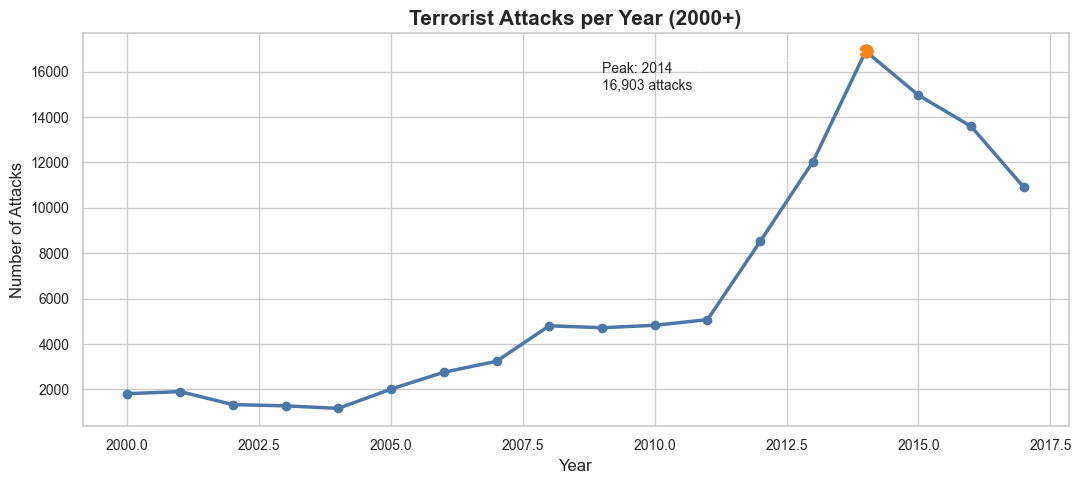

In [6]:
attacks_per_year = df["iyear"].value_counts().sort_index()
peak_year = attacks_per_year.idxmax()
peak_count = attacks_per_year.max()

plt.figure(figsize=(11, 5))
plt.plot(attacks_per_year.index, attacks_per_year.values, marker="o", linewidth=2.5, color=MAIN_COLOR)
plt.scatter([peak_year], [peak_count], s=90, color=ACCENT_COLOR, zorder=3)
plt.annotate(
    f"Peak: {peak_year}\n{peak_count:,} attacks",
    xy=(peak_year, peak_count),
    xytext=(peak_year - 5, peak_count * 0.9),
    arrowprops=dict(arrowstyle="->", lw=1),
    fontsize=10
)
plt.title("Terrorist Attacks per Year (2000+)")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.tight_layout()
plt.show()

The number of recorded attacks increases sharply after 2010 and peaks in the mid-2010s. This suggests that the later portion of the dataset contains a period of especially intense terrorist activity, which makes temporal context useful in the clustering stage.


### Top Countries by Number of Attacks

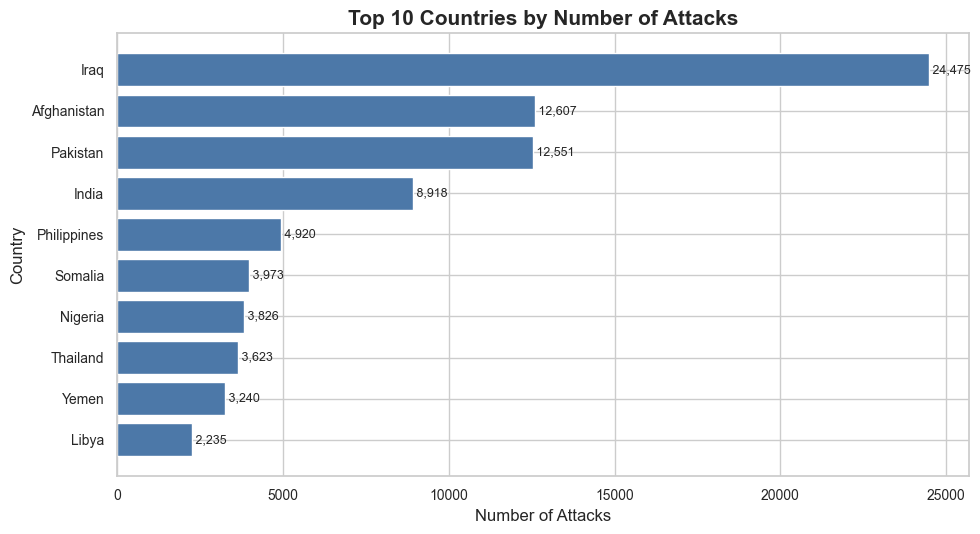

In [7]:
top_countries = df["country_txt"].value_counts().head(10).sort_values()

plt.figure(figsize=(10, 5.5))
bars = plt.barh(top_countries.index, top_countries.values, color=MAIN_COLOR)
plt.title("Top 10 Countries by Number of Attacks")
plt.xlabel("Number of Attacks")
plt.ylabel("Country")
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f" {int(width):,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

A relatively small number of countries account for a large share of attacks. This indicates that terrorism in the dataset is heavily concentrated in particular conflict zones rather than spread evenly across the world.


### Most Common Attack Types

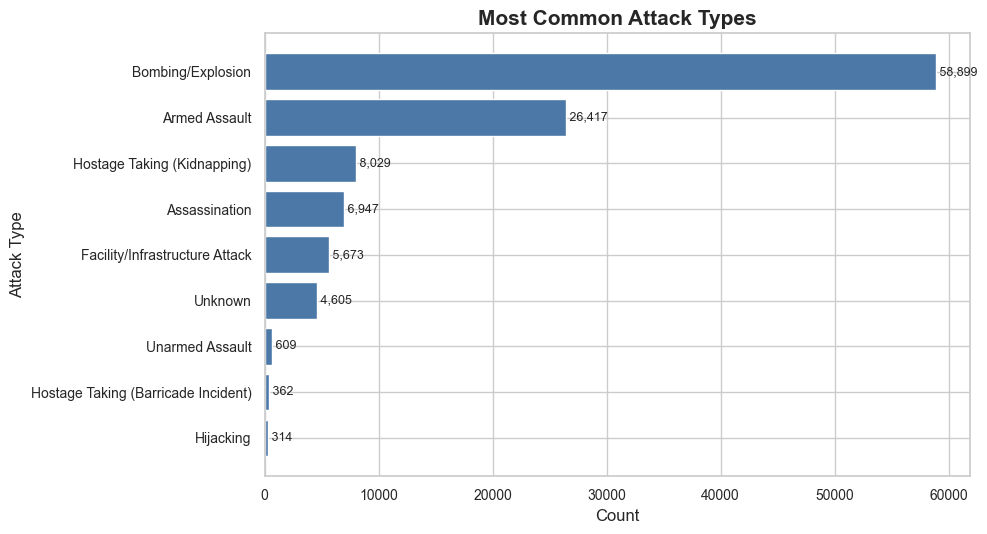

In [8]:
attack_types = df["attacktype1_txt"].value_counts().head(10).sort_values()

plt.figure(figsize=(10, 5.5))
bars = plt.barh(attack_types.index, attack_types.values, color=MAIN_COLOR)
plt.title("Most Common Attack Types")
plt.xlabel("Count")
plt.ylabel("Attack Type")
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f" {int(width):,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

Bombings, armed assaults, and related attack forms dominate the data. This suggests that a few tactical patterns account for much of the activity in the modern GTD subset.


### Most Common Weapon Types

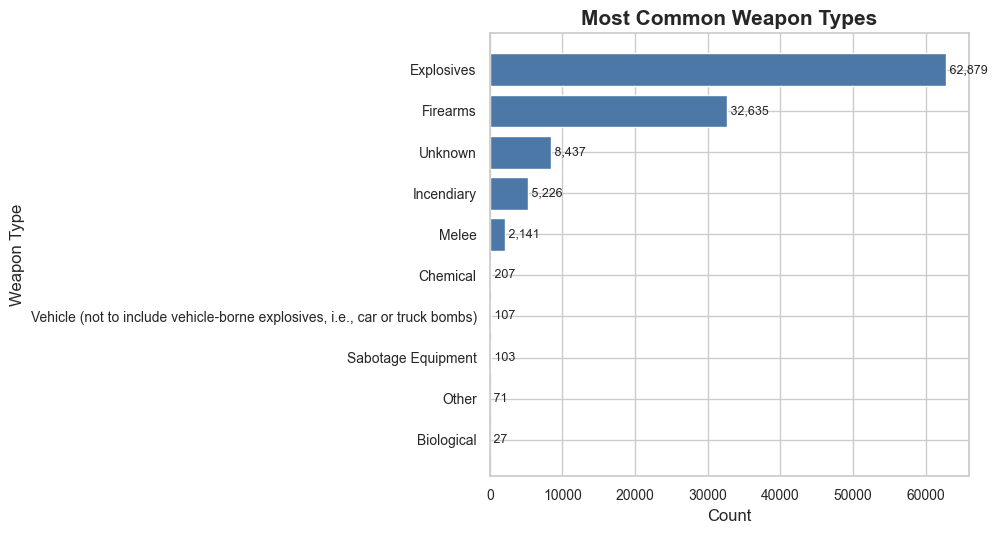

In [9]:
weapon_types = df["weaptype1_txt"].value_counts().head(10).sort_values()

plt.figure(figsize=(10, 5.5))
bars = plt.barh(weapon_types.index, weapon_types.values, color=MAIN_COLOR)
plt.title("Most Common Weapon Types")
plt.xlabel("Count")
plt.ylabel("Weapon Type")
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f" {int(width):,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

Explosives and firearms appear most frequently, which aligns with the attack type distribution and suggests that these weapon categories will be important in distinguishing groups of incidents.


### Casualty Distribution

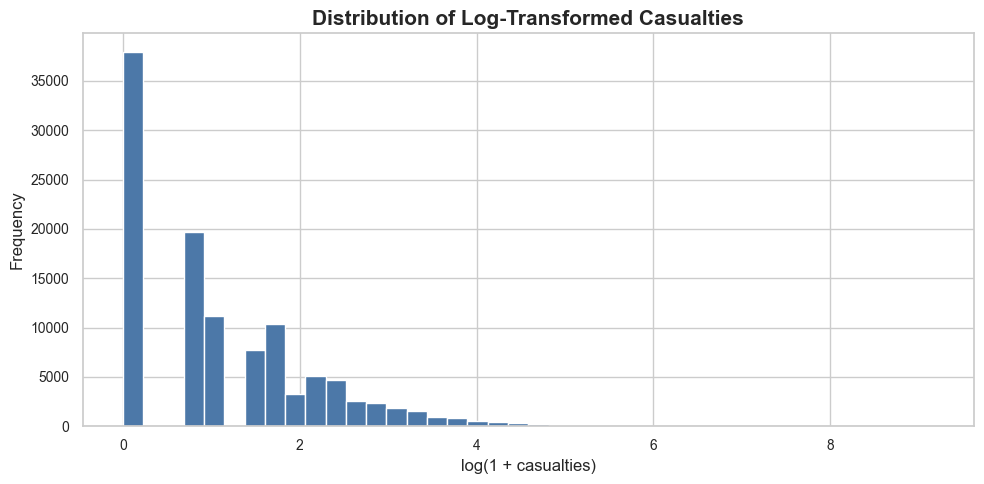

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(df["log_casualties"], bins=40, color=MAIN_COLOR, edgecolor="white")
plt.title("Distribution of Log-Transformed Casualties")
plt.xlabel("log(1 + casualties)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


Most incidents produce relatively few casualties, while a much smaller number cause very high harm. This distribution is strongly skewed, so using `log_casualties` is more appropriate than raw casualty counts for clustering.


### Casualties by Attack Type

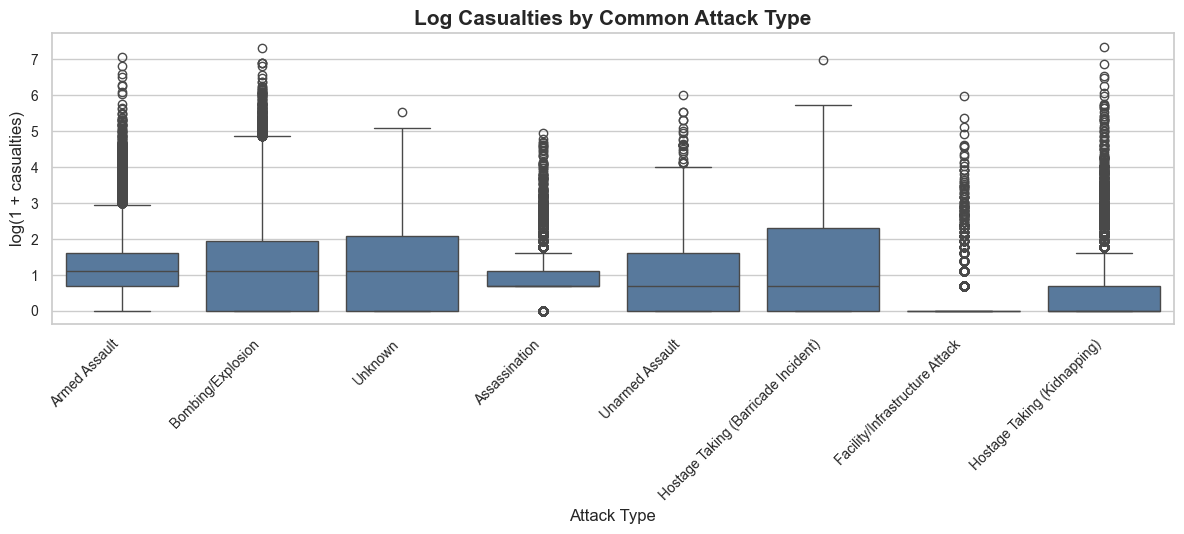

In [11]:
top_attack_categories = df["attacktype1_txt"].value_counts().head(8).index
plot_df = df[df["attacktype1_txt"].isin(top_attack_categories)].copy()
attack_order = plot_df.groupby("attacktype1_txt")["log_casualties"].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 5.5))
sns.boxplot(
    x="attacktype1_txt",
    y="log_casualties",
    data=plot_df,
    order=attack_order,
    color=MAIN_COLOR
)
plt.xticks(rotation=45, ha="right")
plt.title("Log Casualties by Common Attack Type")
plt.xlabel("Attack Type")
plt.ylabel("log(1 + casualties)")
plt.tight_layout()
plt.show()


Attack types differ in their typical severity. Some categories have consistently higher casualty ranges, which supports the idea that severity should be considered alongside categorical descriptors when identifying patterns.


## 7. Encode Features for Clustering

Categorical variables are represented with one-hot encoding so each category becomes its own feature. This lets the clustering algorithms work with category membership directly. The numerical features used here are `log_casualties` and `iyear`.


In [12]:
categorical_cols = ["attacktype1_txt", "targtype1_txt", "weaptype1_txt", "region_txt"]
numeric_cols = ["log_casualties", "iyear"]

df_encoded = pd.get_dummies(df[categorical_cols], prefix=categorical_cols)
feature_df = pd.concat([df_encoded, df[numeric_cols]], axis=1)

print("Encoded feature matrix shape:", feature_df.shape)
feature_df.head()


Encoded feature matrix shape: (111855, 57)


,attacktype1_txt_Armed Assault,attacktype1_txt_Assassination,attacktype1_txt_Bombing/Explosion,attacktype1_txt_Facility/Infrastructure Attack,attacktype1_txt_Hijacking,attacktype1_txt_Hostage Taking (Barricade Incident),attacktype1_txt_Hostage Taking (Kidnapping),attacktype1_txt_Unarmed Assault,attacktype1_txt_Unknown,targtype1_txt_Abortion Related,...,region_txt_Eastern Europe,region_txt_Middle East & North Africa,region_txt_North America,region_txt_South America,region_txt_South Asia,region_txt_Southeast Asia,region_txt_Sub-Saharan Africa,region_txt_Western Europe,log_casualties,iyear
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,2.079442,2000
1,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,2.079442,2000
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,1.386294,2000
3,False,False,True,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,0.693147,2000
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,2.833213,2000


## 8. Standardize Features

In [13]:
scaler = StandardScaler()
X = scaler.fit_transform(feature_df)

print("Scaled feature matrix shape:", X.shape)


Scaled feature matrix shape: (111855, 57)


## 9. K-Means Model Selection

The number of clusters is evaluated with both the elbow method and silhouette scores. Because this is a large dataset with many categorical indicators, the metrics are computed on a reproducible random sample to keep runtime manageable.


In [14]:
sample_n = min(10000, len(df))
sample_positions = np.random.RandomState(0).choice(len(df), size=sample_n, replace=False)

X_sample = X[sample_positions]
print("Sample used for elbow and silhouette analysis:", X_sample.shape)


Sample used for elbow and silhouette analysis: (10000, 57)


### Elbow Method

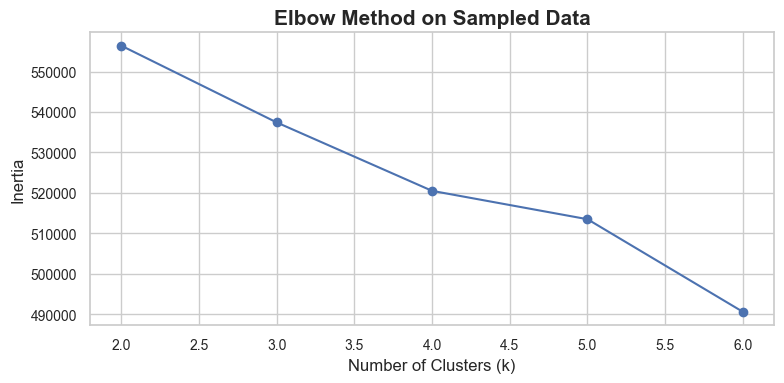

In [15]:
inertia = []
k_values = list(range(2, 7))

for k in k_values:
    model = KMeans(n_clusters=k, random_state=0, n_init=10)
    model.fit(X_sample)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_values, inertia, marker="o")
plt.title("Elbow Method on Sampled Data")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()


### Silhouette Scores

In [16]:
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = model.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    "k": k_values,
    "silhouette_score": silhouette_scores
})

silhouette_results


,k,silhouette_score
0,2,0.124055
1,3,0.115870
2,4,0.129741
3,5,0.132302
4,6,0.131290


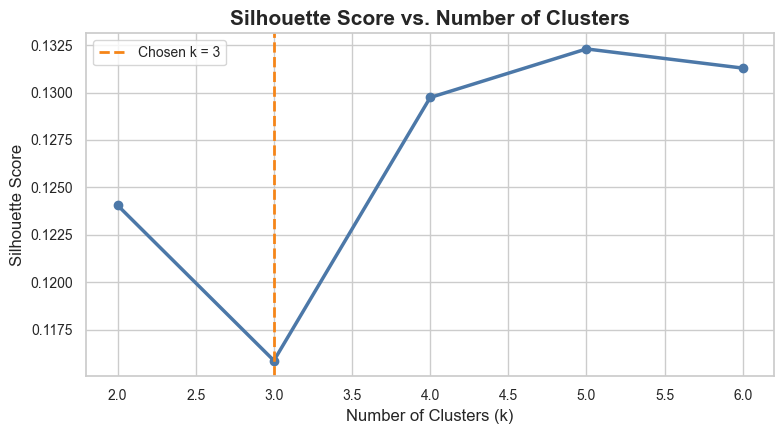

In [17]:
plt.figure(figsize=(8, 4.5))
plt.plot(k_values, silhouette_scores, marker="o", linewidth=2.5, color=MAIN_COLOR)
plt.axvline(3, color=ACCENT_COLOR, linestyle="--", linewidth=2, label="Chosen k = 3")
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.tight_layout()
plt.show()


The elbow curve is gradual rather than sharply bent, so it does not clearly identify a single best value of k. The silhouette scores are also important because they show that **k = 3 is not the highest-scoring option**; slightly higher silhouette values occur at larger k values. However, **k = 3** is still used because it produces a smaller, more interpretable set of clusters that can be explained clearly in domain terms.


## 10. Final K-Means Clustering

In [18]:
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
df["cluster"] = kmeans.fit_predict(X)

df[["cluster"]].head()


,cluster
0,2
1,2
2,2
3,0
4,2


In [19]:
cluster_names = {
    0: "Bombing/Explosive Attacks in MENA",
    1: "Unarmed/Military-Targeted Incidents",
    2: "Armed Assaults in South Asia"
}

df["cluster_name"] = df["cluster"].map(cluster_names)

df[["cluster", "cluster_name"]].head()


,cluster,cluster_name
0,2,Armed Assaults in South Asia
1,2,Armed Assaults in South Asia
2,2,Armed Assaults in South Asia
3,0,Bombing/Explosive Attacks in MENA
4,2,Armed Assaults in South Asia


### Cluster Sizes

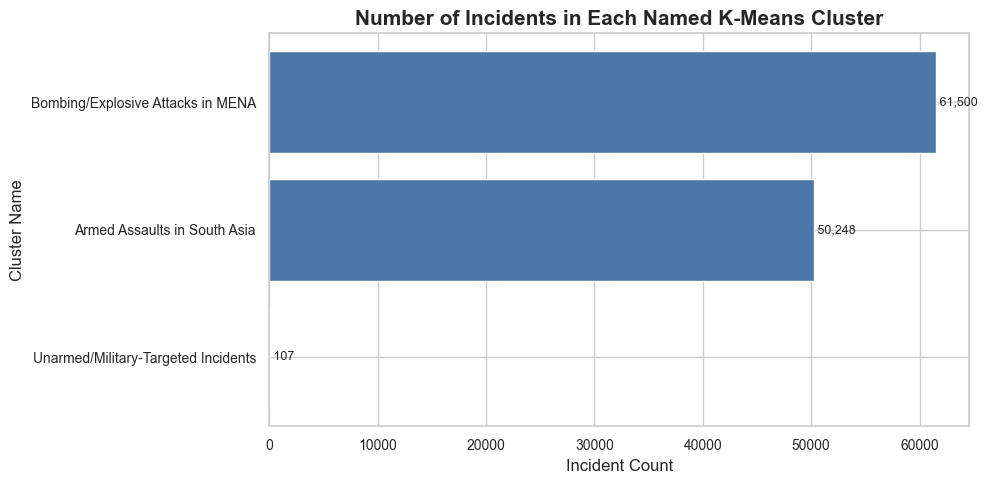

In [20]:
cluster_counts = df["cluster_name"].value_counts().sort_values()

plt.figure(figsize=(10, 5))
bars = plt.barh(cluster_counts.index, cluster_counts.values, color=MAIN_COLOR)
plt.title("Number of Incidents in Each Named K-Means Cluster")
plt.xlabel("Incident Count")
plt.ylabel("Cluster Name")
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f" {int(width):,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


The cluster counts show how incidents are distributed across the three broad groups. This gives an immediate sense of whether the segmentation is balanced or dominated by one large cluster.


### Cluster Profile Summary

In [21]:
cluster_numeric_summary = df.groupby("cluster")[["casualties", "log_casualties", "iyear"]].agg(["mean", "median"])
cluster_numeric_summary


casualties        log_casualties                  iyear        
               mean median           mean    median         mean  median
cluster                                                                 
0          7.180829    2.0       1.204170  1.098612  2012.224585  2013.0
1        188.383178    3.0       1.529923  1.386294  2013.570093  2015.0
2          3.935062    1.0       0.945903  0.693147  2012.273105  2014.0

This summary table shows how the clusters differ in severity and time period. Differences in average or median casualty levels help distinguish lower-impact incidents from more severe ones, while year patterns indicate whether some clusters are associated with particular time periods.


### Most Common Categories by Cluster

In [22]:
def top_category_per_cluster(dataframe, cluster_col, category_col):
    result = (
        dataframe.groupby(cluster_col)[category_col]
        .agg(lambda x: x.value_counts().index[0])
        .rename(f"top_{category_col}")
    )
    return result

cluster_top_categories = pd.concat([
    top_category_per_cluster(df, "cluster", "attacktype1_txt"),
    top_category_per_cluster(df, "cluster", "targtype1_txt"),
    top_category_per_cluster(df, "cluster", "weaptype1_txt"),
    top_category_per_cluster(df, "cluster", "region_txt")
], axis=1)

cluster_top_categories


,top_attacktype1_txt,top_targtype1_txt,top_weaptype1_txt,top_region_txt
cluster,,,,
0,Bombing/Explosion,Private Citizens & Property,Explosives,Middle East & North Africa
1,Unarmed Assault,Military,Vehicle (not to include vehicle-borne explosiv...,Middle East & North Africa
2,Armed Assault,Private Citizens & Property,Firearms,South Asia


The most common categories in each cluster make the cluster patterns easier to interpret in domain terms. Instead of thinking only in terms of cluster numbers, this table highlights the attack types, targets, weapons, and regions that characterize each group most clearly.


### Named Cluster Interpretation

Based on the cluster profile table above, the numerical cluster labels can be translated into more meaningful descriptions. These names are not new model outputs; they are interpretive labels based on the most common attack type, target type, weapon type, region, and casualty profile for each cluster.


In [23]:
cluster_name_summary = (
    df.groupby("cluster_name")
    .agg(
        incident_count=("cluster", "size"),
        mean_casualties=("casualties", "mean"),
        median_casualties=("casualties", "median"),
        median_year=("iyear", "median"),
        top_region=("region_txt", lambda x: x.value_counts().index[0]),
        top_attack_type=("attacktype1_txt", lambda x: x.value_counts().index[0]),
        top_target_type=("targtype1_txt", lambda x: x.value_counts().index[0]),
        top_weapon_type=("weaptype1_txt", lambda x: x.value_counts().index[0]),
    )
    .sort_values("incident_count", ascending=False)
)

cluster_name_summary


,incident_count,mean_casualties,median_casualties,median_year,top_region,top_attack_type,top_target_type,top_weapon_type
cluster_name,,,,,,,,
Bombing/Explosive Attacks in MENA,61500,7.180829,2.0,2013.0,Middle East & North Africa,Bombing/Explosion,Private Citizens & Property,Explosives
Armed Assaults in South Asia,50248,3.935062,1.0,2014.0,South Asia,Armed Assault,Private Citizens & Property,Firearms
Unarmed/Military-Targeted Incidents,107,188.383178,3.0,2015.0,Middle East & North Africa,Unarmed Assault,Military,Vehicle (not to include vehicle-borne explosiv...


Naming the clusters makes the discovery results easier to explain. Cluster 0 is mainly associated with bombing/explosive attacks in the Middle East and North Africa. Cluster 1 is unusual because its most common profile involves unarmed attacks against military targets. Cluster 2 is associated with armed assaults using firearms in South Asia. These labels make the cluster results more concrete than referring only to cluster numbers.


## 11. PCA Visualization of K-Means Clusters

PCA reduces the high-dimensional feature space to two components for visualization. This does not replace the full clustering model; it simply provides a lower-dimensional view of how the incidents separate when all standardized features are considered together.


In [24]:
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X)

explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio (PC1, PC2):", explained_variance)
print("Total explained variance (2 PCs):", explained_variance.sum())


Explained variance ratio (PC1, PC2): [0.06129298 0.04078698]
Total explained variance (2 PCs): 0.10207996279599452


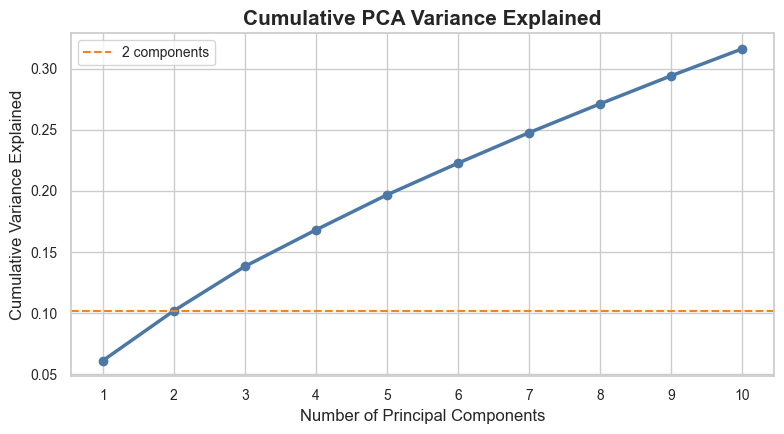

In [25]:
pca_check = PCA(n_components=10, random_state=0)
pca_check.fit(X)
cumulative_variance = np.cumsum(pca_check.explained_variance_ratio_)

plt.figure(figsize=(8, 4.5))
plt.plot(range(1, 11), cumulative_variance, marker="o", linewidth=2.5, color=MAIN_COLOR)
plt.axhline(cumulative_variance[1], color=ACCENT_COLOR, linestyle="--", label="2 components")
plt.title("Cumulative PCA Variance Explained")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()


This plot makes the PCA limitation visible. The first two components are useful for a compact visual sketch, but they explain only a small portion of the total variance. The higher-dimensional clustering results should therefore be interpreted using the full feature space and the cluster profile tables, not the 2D plot alone.


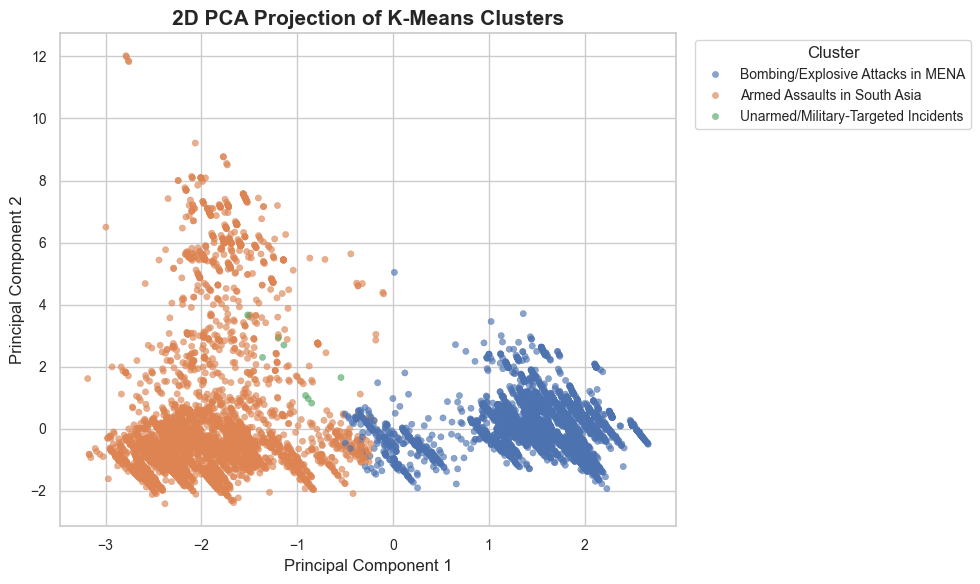

In [26]:
plot_n = min(12000, len(df))
plot_positions = np.random.RandomState(0).choice(len(df), size=plot_n, replace=False)

pca_plot_df = pd.DataFrame({
    "PC1": X_pca[plot_positions, 0],
    "PC2": X_pca[plot_positions, 1],
    "Cluster": df.loc[plot_positions, "cluster_name"].values
})

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    s=20,
    alpha=0.65,
    edgecolor=None
)
plt.title("2D PCA Projection of K-Means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


The 2D PCA projection is useful as a rough visual summary, but it should not be treated as strong evidence of cluster separation by itself. The first two principal components capture only a limited portion of the full feature space, so the actual K-Means clusters are defined in the original high-dimensional standardized feature matrix, not only in this 2D plot.


## 12. DBSCAN as an Alternative Clustering Approach

DBSCAN is useful here because it does not require pre-specifying the number of clusters and can label unusual points as noise. Since density-based clustering can be computationally heavy in high dimensions, PCA is used first to reduce dimensionality before applying DBSCAN to a sample.


In [27]:
pca_db = PCA(n_components=10, random_state=0)
X_pca10 = pca_db.fit_transform(X)

dbscan_n = min(8000, len(df))
dbscan_positions = np.random.RandomState(0).choice(len(df), size=dbscan_n, replace=False)
X_db = X_pca10[dbscan_positions]

print("DBSCAN sample shape:", X_db.shape)
print("Variance captured by 10 PCs:", pca_db.explained_variance_ratio_.sum())


DBSCAN sample shape: (8000, 10)
Variance captured by 10 PCs: 0.3161555535011735


### Parameter Exploration for DBSCAN

In [28]:
dbscan_trials = []

for eps in [1.2, 1.5, 1.8]:
    for min_samples in [10, 20]:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_db)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (labels == -1).mean() * 100
        dbscan_trials.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters_found": n_clusters,
            "noise_percent": round(noise_pct, 2)
        })

dbscan_trials_df = pd.DataFrame(dbscan_trials)
dbscan_trials_df


,eps,min_samples,clusters_found,noise_percent
0,1.2,10,93,17.34
1,1.2,20,62,24.62
2,1.5,10,53,12.49
3,1.5,20,36,18.39
4,1.8,10,18,7.48
5,1.8,20,10,10.98


This parameter table shows how sensitive DBSCAN is to `eps` and `min_samples`. The results indicate that DBSCAN does not produce one small, clean set of broad clusters for this dataset. Instead, the method tends to fragment the data into many smaller density-based groups and a noticeable noise category.


### Selected DBSCAN Result

The following cell runs DBSCAN with the selected parameters, creates the result table, summarizes cluster sizes, and prepares the data used for the visualization. Keeping these steps together prevents later cells from depending on variables that were not created yet.


In [29]:
# Selected DBSCAN settings
dbscan = DBSCAN(eps=1.5, min_samples=20)
db_labels = dbscan.fit_predict(X_db)

# Store the result used by later summaries and plots
dbscan_results = pd.DataFrame({
    "pc1": X_db[:, 0],
    "pc2": X_db[:, 1],
    "db_cluster": db_labels
})

# Summarize cluster and noise counts
dbscan_summary = (
    dbscan_results["db_cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

dbscan_summary.columns = ["cluster_label", "count"]
dbscan_summary["percent"] = (
    dbscan_summary["count"] / dbscan_summary["count"].sum() * 100
).round(2)

dbscan_summary


,cluster_label,count,percent
0,-1,1471,18.39
1,0,4193,52.41
2,1,68,0.85
3,2,722,9.02
4,3,91,1.14
5,4,28,0.35
6,5,80,1.00
7,6,124,1.55
8,7,48,0.60
9,8,23,0.29


The label `-1` represents noise points. A large number of small cluster labels indicates that DBSCAN fragments the dataset into many local density-based groups rather than producing a few broad clusters.


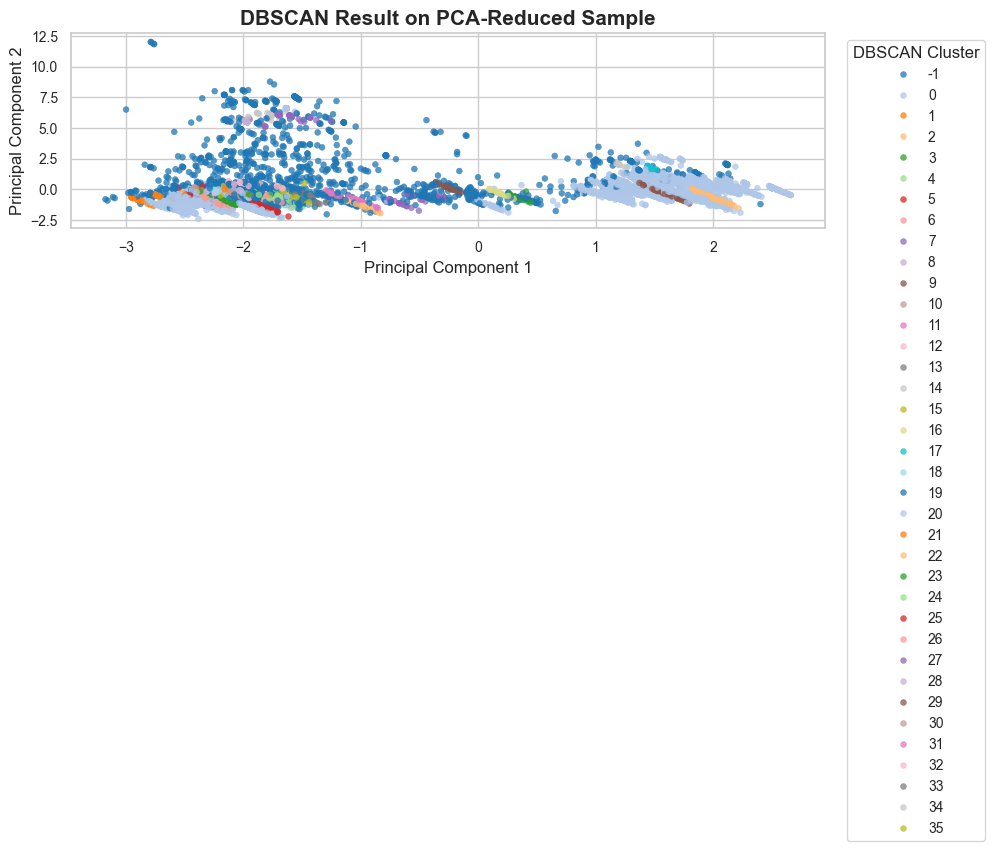

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=dbscan_results,
    x="pc1",
    y="pc2",
    hue="db_cluster",
    palette="tab20",
    s=18,
    alpha=0.75,
    edgecolor=None
)
plt.title("DBSCAN Result on PCA-Reduced Sample")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="DBSCAN Cluster", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)
plt.tight_layout()
plt.show()


DBSCAN provides a different view of the data than K-Means, but the selected parameters produce many small clusters rather than a few clean groups. This is still a meaningful result: it suggests that the terrorism dataset has complex local density structure and does not naturally organize into a small number of compact density-based clusters.


## 13. Decision Tree for Cluster Interpretation

A decision tree is used here as an interpretability tool rather than as a pure prediction model. By treating the K-Means cluster labels as classes, the tree shows which features are most useful for distinguishing clusters and turns those differences into readable rules.


The decision tree is now plotted with feature names, making it easier to interpret. Its purpose is not to predict future attacks, but to explain which encoded features and severity measures distinguish the K-Means clusters. This turns the clustering output into a more readable set of decision rules.


## Decision Tree for Cluster Interpretation

A decision tree is used here as an interpretability tool rather than as a predictive model. By treating the K-Means cluster labels as classes, the tree shows which features are most useful for distinguishing the named clusters.


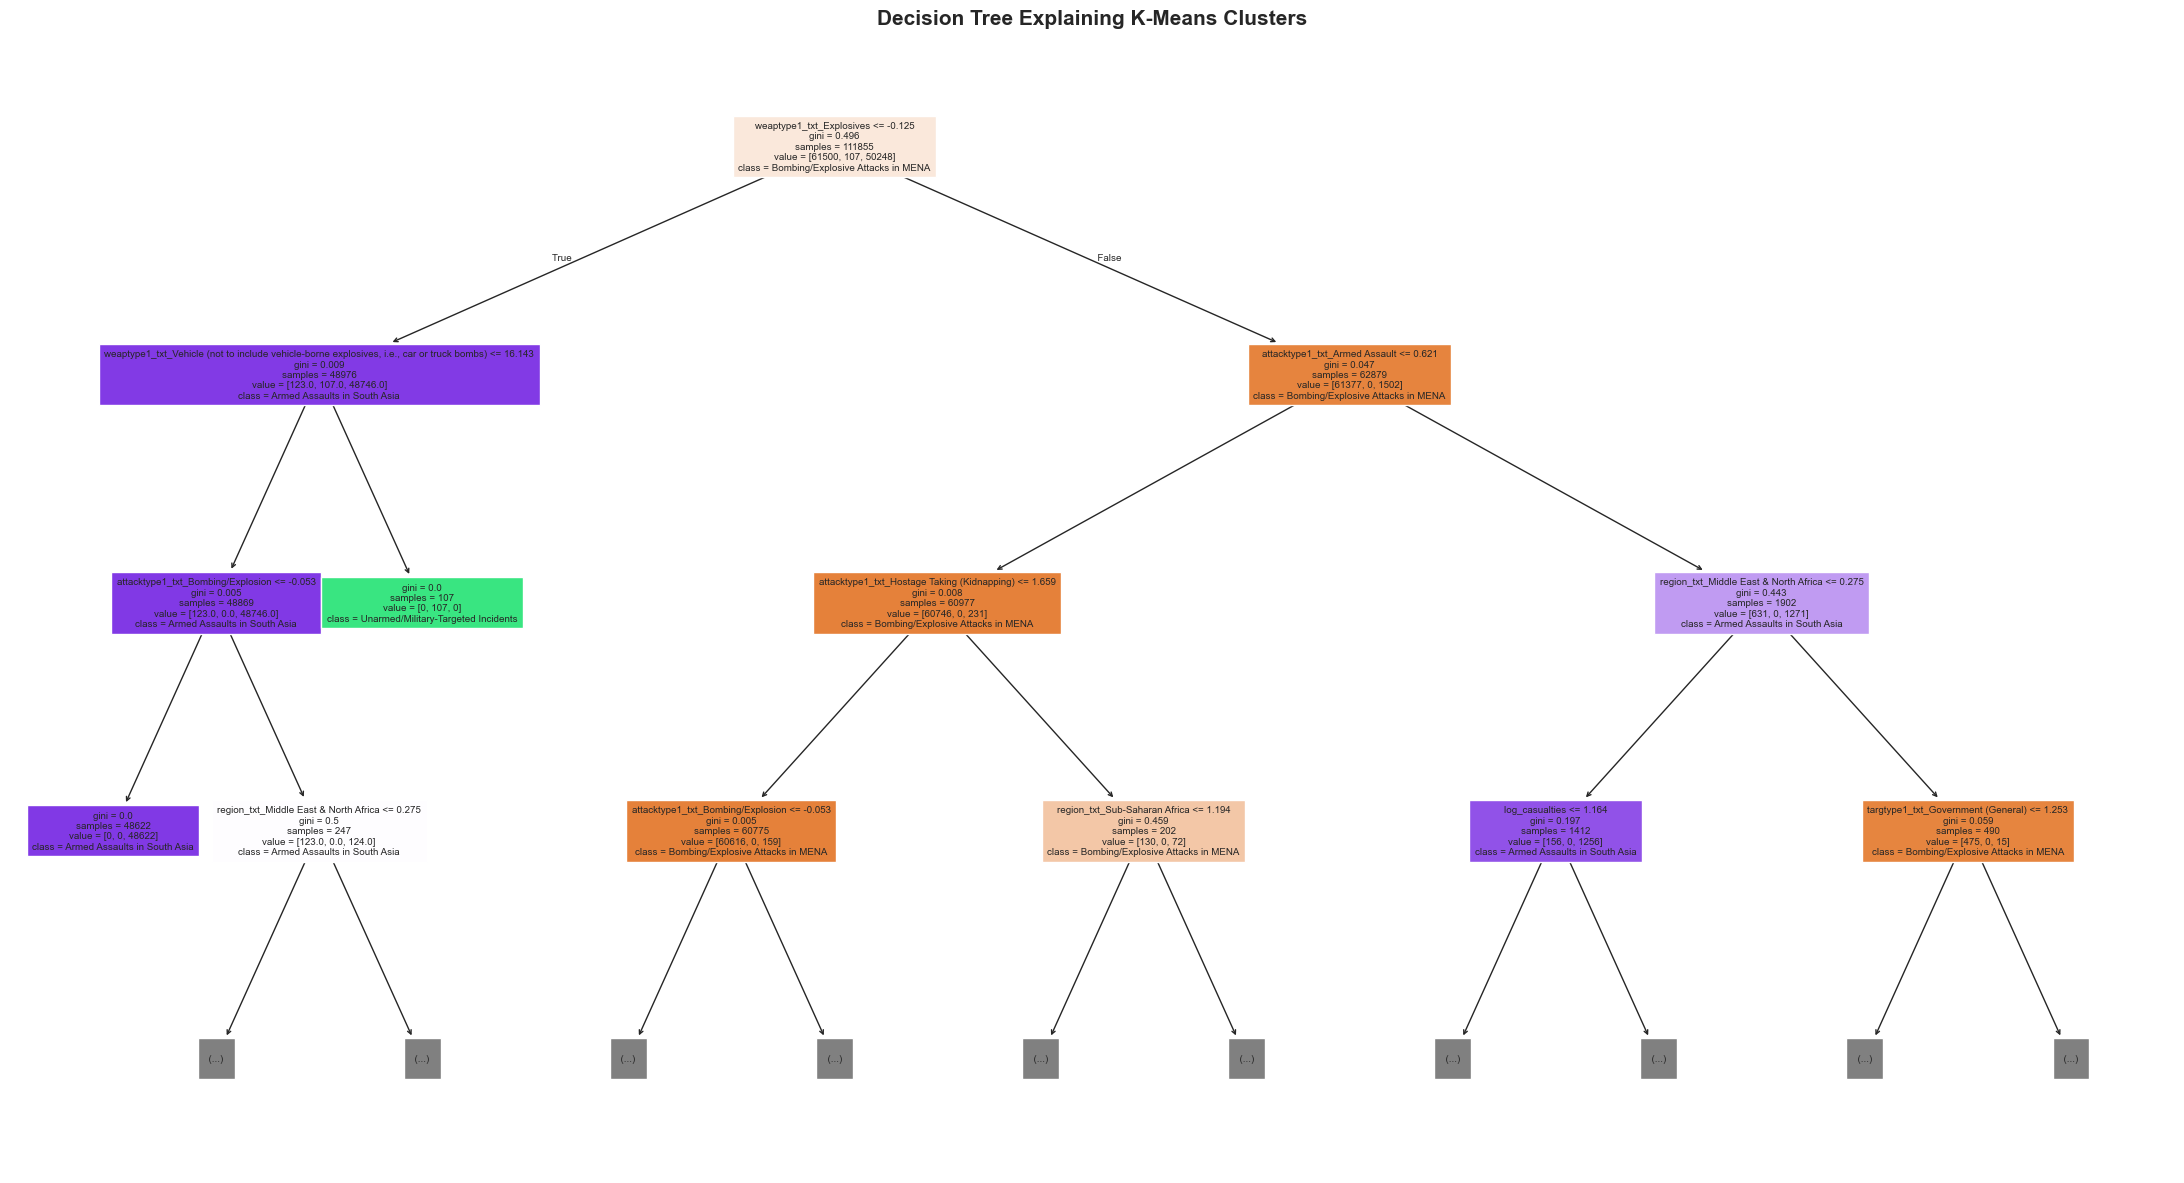

In [31]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=0)
tree_model.fit(X, df["cluster"])

plt.figure(figsize=(22, 12))
plot_tree(
    tree_model,
    filled=True,
    feature_names=feature_df.columns.tolist(),
    class_names=[cluster_names[i] for i in sorted(cluster_names.keys())],
    max_depth=3,
    fontsize=7
)
plt.title("Decision Tree Explaining K-Means Clusters")
plt.tight_layout()
plt.show()


The decision tree uses the full feature matrix and displays readable feature names. This makes the cluster structure easier to interpret because the splits point to the features that most strongly separate the named clusters.


## 14. Comparing K-Means and DBSCAN

The two clustering methods answer slightly different questions. K-Means is useful for broad segmentation across the full dataset, while DBSCAN is more useful for finding dense local structure and identifying noise points. Using both methods gives a fuller picture of the data than either one alone.


## 15. Discovery Question Progress

### Discovery Question 1: Are there natural clusters of terrorist incidents based on attack characteristics?

Yes. K-Means suggests that the incidents can be partitioned into three broad groups when attack type, target type, weapon type, severity, region, and year are considered together.

### Discovery Question 2: How do geographic and temporal context affect the clustering structure?

Region and year contribute useful context because attacks are not defined only by tactics. The concentration of incidents in specific regions and the strong variation over time suggest that clustering improves when those dimensions are included.

### Discovery Question 3: What additional structure appears when a density-based clustering method is used?

DBSCAN reveals that some incidents behave like members of dense local groups, while others appear as noise. This suggests that the dataset contains both common recurring patterns and more unusual event types that do not fit neatly into broad centroid-based segments.


## 16. Final Interpretation

The analysis shows that modern terrorist incidents are not a single homogeneous type of event. Instead, the data can be organized into meaningful patterns that differ in tactics, targets, weapons, region, time period, and severity.

The clearest discovery output is the named cluster profile: bombing/explosive attacks in the Middle East and North Africa, unarmed/military-targeted incidents, and armed assaults in South Asia. K-Means provides the broad segmentation, the decision tree helps explain those groups, PCA offers a limited but useful visualization, and DBSCAN shows that the data does not reduce cleanly into a small number of density-based clusters.


## 17. M4 Plan

For M4, the technical work is largely complete. The remaining tasks are to refine cluster names, strengthen the limitations discussion, improve presentation quality, and sharpen the written interpretation so the final story is clearer and more polished.
